In [3]:
# importing the necessary 
from langgraph.graph import StateGraph, START, END 
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages,BaseMessage
from langchain_core.messages import HumanMessage, SystemMessage 
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv 

from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

In [4]:
# load the environment vaiable
load_dotenv()

True

In [5]:
# LLM 
llm = ChatOpenAI()

In [27]:
#1.building tools 
search_tool = DuckDuckGoSearchRun(region="us-en")

# 2 calculator tool 
@tool
def calculator(first_num:float, second_num:float, operator: str):

    """
    Perform the arithmatic operator on the given two numbers.
    Supported operations: add, sub, multi, div
    """

    try:
        if operator=="add":
            result = first_num+second_num

        elif operator=="sub":
            result = first_num-second_num 

        elif operator =="multi":
            result = first_num*second_num

        elif operator=="div":
            if second_num==0:
                return ZeroDivisionError
            else:
                result = first_num/second_num 
        else:
            return {"error":f"unsupported operator {operator}"}
        
        return {"first_num":first_num, "second_num":second_num, "operator":operator,"result":result}
    except Exception as e:
        return {"error":str(e)}
    

# 3 get stock_price tool 

@tool
def get_stock_price(symbol: str) -> dict: 

    """
    Get the stock price of the company from the given symbol. eg.('AAPL','TSLA)
    With using Alpha vantage with API key in the url.

    
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=SXLEKX8DW3VX5IH1"
    r = requests.get(url)
    return r.json()

In [18]:
# make the tool list 
tools = [search_tool,calculator, get_stock_price]

# make the llm tool aware 
llm_with_tools = llm.bind_tools(tools)

In [28]:
# define the state of the graph 

class ChatState(TypedDict): 

    messages :Annotated[list[BaseMessage], add_messages]

In [30]:
# chat node 
def ChatNode(state:ChatState) -> ChatState:
    """llm tool that may answe or request a tool call"""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)

    return {"messages":[response]}

# tool node
tool_node = ToolNode(tools)


In [31]:
# start bulding the graph 
graph = StateGraph(ChatState)

graph.add_node(ChatNode)
graph.add_node(tool_node)


In [32]:
# add the edges to the graph 
graph.add_edge(START, "ChatNode")
# if llm got request to go to the tool then hit the tool node 
graph.add_conditional_edges("ChatNode",tools_condition)
# add the loop between tool and the chatnode 
graph.add_edge("tools","ChatNode")

In [33]:
chatbot = graph.compile()

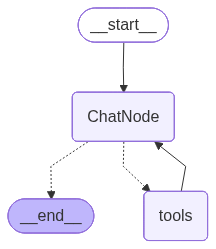

In [34]:
chatbot

In [35]:
# invoking calculator tool 
out =chatbot.invoke({"messages":[HumanMessage(content="What is 2*7")]})
print(out["messages"][-1].content)

The result of 2 multiplied by 7 is 14.


In [37]:
  # invoking DDGS tool 
out1 = chatbot.invoke({"messages":[HumanMessage(content="What is the current stock proce of apple in INR?")]})
print(out1['messages'][-1].content)

The current stock price of Apple (AAPL) is $262.36. Please note that the stock price is provided in USD.
